# LSTM Sequence Model — AQI Forecasting

A sequence-based neural network that predicts daily AQI using LSTM layers.
Unlike classical ML models that consume a single feature vector per sample,
this model ingests a **sliding window** of consecutive days and learns
temporal dependencies directly from the raw sequence.

Key design choices:
- **Sliding window per city**: sequences are only formed within contiguous
  date blocks so the model never sees a gap as if it were consecutive data.
- **Full tabular feature set** (same as the FNN): each timestep in the
  sliding window uses the same engineered features — pollutants, missing
  flags, calendar, AQI lags/rolling stats, pollutant lags, city dummies —
  so the LSTM has the same predictive signals as the feed-forward model.
- **Log-transformed target**: consistent with all other project models;
  predictions are inverted with `expm1` before evaluation.
- **Temporal validation**: a held-out window (Oct–Nov 2019) is used for
  early stopping and hyperparameter selection, mirroring the k-NN notebook.

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import copy

from preprocessing import (
    load_and_prepare, impute, build_features,
    get_train_test, evaluate, save_results,
    POLLUTANT_COLS, AQI_LABELS, CUTOFF_DATE,
)

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'


## 1. load and prepare data

In [ ]:
df = load_and_prepare()
df = impute(df)
df, feature_cols = build_features(df)

seq_feature_cols = feature_cols

print(f'sequence features per timestep: {len(seq_feature_cols)}')
print(f'total rows in dataset: {len(df):,}')

sequence features per timestep: 70
total rows in dataset: 24,850


## 2. sequence dataset

For each city the data is sorted by date, then split into **contiguous
date blocks** (no gaps). Within each block, sliding windows of length `W`
are extracted:

```
X = features at days [t-W, t-W+1, …, t-1]   shape (W, F)
y = log1p(AQI) at day t                       scalar
```

A `StandardScaler` is fit on training sequences and reused for
validation / test to prevent data leakage.

In [4]:
class AQISequenceDataset(Dataset):
    """Sliding-window dataset for AQI time-series, per city."""

    def __init__(self, df, feature_cols, window_size,
                 scaler=None, fit_scaler=False):
        self.window_size = window_size
        self.feature_cols = feature_cols

        df = df.copy()

        # fill residual NaNs
        for col in feature_cols:
            if (col.startswith(('city_', 'season_'))
                    or col.endswith('_missing') or col == 'is_weekend'):
                df[col] = df[col].fillna(0)
            else:
                df[col] = df[col].fillna(df[col].median())

        raw = df[feature_cols].values.astype(np.float32)

        if fit_scaler:
            self.scaler = StandardScaler()
            raw = self.scaler.fit_transform(raw).astype(np.float32)
        elif scaler is not None:
            self.scaler = scaler
            raw = self.scaler.transform(raw).astype(np.float32)
        else:
            self.scaler = None

        self.sequences = []        # (X_window, y_target)
        self.raw_targets = []      # original-scale AQI for evaluation
        self.target_dates = []
        self.target_cities = []

        for city, city_df in df.groupby('city'):
            city_df = city_df.sort_values('date').reset_index(drop=True)
            idx_map = city_df.index.values     # position inside `raw`
            # we need the *original* integer positions in df
            orig_idx = df.index[df['city'] == city]
            orig_idx = orig_idx[city_df.index]  # aligned

            dates    = city_df['date'].values
            targets  = city_df['aqi_log'].values.astype(np.float32)
            raw_aqi  = city_df['aqi'].values.astype(np.float32)

            # contiguous date blocks
            diffs = np.diff(dates).astype('timedelta64[D]').astype(int)
            breaks = np.where(diffs > 1)[0] + 1
            blocks = np.split(np.arange(len(city_df)), breaks)

            for block in blocks:
                if len(block) <= window_size:
                    continue
                for i in range(window_size, len(block)):
                    win_pos = orig_idx[block[i - window_size:i]]
                    X = raw[win_pos]
                    y = targets[block[i]]
                    self.sequences.append((
                        torch.from_numpy(X),
                        torch.tensor(y),
                    ))
                    self.raw_targets.append(float(raw_aqi[block[i]]))
                    self.target_dates.append(dates[block[i]])
                    self.target_cities.append(city)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

## 3. Model definition

A stacked LSTM with a **skip connection**: the last timestep's feature vector
is concatenated with the LSTM's final hidden state, then dropout and a single
linear layer produce `log1p(AQI)`. This lets the model use the same "last day"
tabular input the FNN sees, while the LSTM can add sequence context.

In [5]:
class AQIForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=64,
                 num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        # Skip connection: last hidden + last timestep features (same info FNN sees per day)
        self.fc = nn.Linear(hidden_size + input_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        _, (h_n, _) = self.lstm(x)
        last_h = h_n[-1]
        last_x = x[:, -1, :]
        combined = torch.cat([last_h, last_x], dim=1)
        out = self.dropout(combined)
        return self.fc(out).squeeze(-1)

## 3a. Baseline LSTM

In [17]:
from torch.utils.data import DataLoader

# Config you want to compare
W_ALT  = 7
H_ALT  = 64
L_ALT  = 1
LR_ALT = 5e-4  # 0.0005

# Build datasets/loaders
train_ds_alt = AQISequenceDataset(train_sub_df, seq_feature_cols, W_ALT, fit_scaler=True)
val_ds_alt   = AQISequenceDataset(val_sub_df,   seq_feature_cols, W_ALT, scaler=train_ds_alt.scaler)
test_ds_alt  = AQISequenceDataset(test_df,      seq_feature_cols, W_ALT, scaler=train_ds_alt.scaler)

val_raw_aqi_alt  = np.array(val_ds_alt.raw_targets)
test_raw_aqi_alt = np.array(test_ds_alt.raw_targets)

train_loader_alt = DataLoader(train_ds_alt, batch_size=128, shuffle=True)
val_loader_alt   = DataLoader(val_ds_alt,   batch_size=256, shuffle=False)
test_loader_alt  = DataLoader(test_ds_alt,  batch_size=256, shuffle=False)

# Train this specific config
model_alt = AQIForecaster(
    input_size=len(seq_feature_cols),
    hidden_size=H_ALT,
    num_layers=L_ALT,
    dropout=0.2,
)

model_alt, _, _, best_rmse_alt, best_mae_alt, best_r2_alt = train_model(
    model_alt, train_loader_alt, val_loader_alt, val_raw_aqi_alt,
    epochs=80, lr=LR_ALT, weight_decay=1e-5, patience=10,
    device=DEVICE, verbose=True,
)

print(f"Best val RMSE={best_rmse_alt:.2f}, MAE={best_mae_alt:.2f}, R²={best_r2_alt:.4f}")

# Test-set evaluation to get per-category MAE
model_alt.eval()
test_preds_alt = []
with torch.no_grad():
    for X_b, _ in test_loader_alt:
        test_preds_alt.append(model_alt(X_b.to(DEVICE)).cpu().numpy())
test_preds_alt = np.clip(np.expm1(np.concatenate(test_preds_alt)), 0, None)

label_alt = f"LSTM (w={W_ALT}, h={H_ALT}, L={L_ALT}, lr={LR_ALT})"
result_alt = evaluate(test_raw_aqi_alt, test_preds_alt, label=label_alt)

result_alt

  epoch   1 | loss 12.4729 | val RMSE 102.99
  epoch  10 | loss 0.1523 | val RMSE 68.46
  epoch  20 | loss 0.1375 | val RMSE 63.75
  epoch  30 | loss 0.1287 | val RMSE 76.53
  early stop @ epoch 32
Best val RMSE=63.22, MAE=34.80, R²=0.7915

──────────────────────────────────────────────────────
  LSTM (w=7, h=64, L=1, lr=0.0005)
──────────────────────────────────────────────────────
  RMSE :    39.96
  MAE  :    22.62
  R²   :   0.8048
  MAE by AQI category:
              Good:   16.48  (n=476)
      Satisfactory:   13.11  (n=1,929)
          Moderate:   24.02  (n=1,540)
              Poor:   44.64  (n=349)
         Very Poor:   42.10  (n=203)
            Severe:  158.77  (n=55)


{'label': 'LSTM (w=7, h=64, L=1, lr=0.0005)',
 'RMSE': 39.96127749266796,
 'MAE': 22.623059671457288,
 'R2': 0.8048415847498877,
 'MAE_Good': 16.47988819875637,
 'MAE_Satisfactory': 13.1059445059318,
 'MAE_Moderate': 24.02452035631452,
 'MAE_Poor': 44.63799423611267,
 'MAE_Very Poor': 42.097056910322216,
 'MAE_Severe': 158.76818181818183}

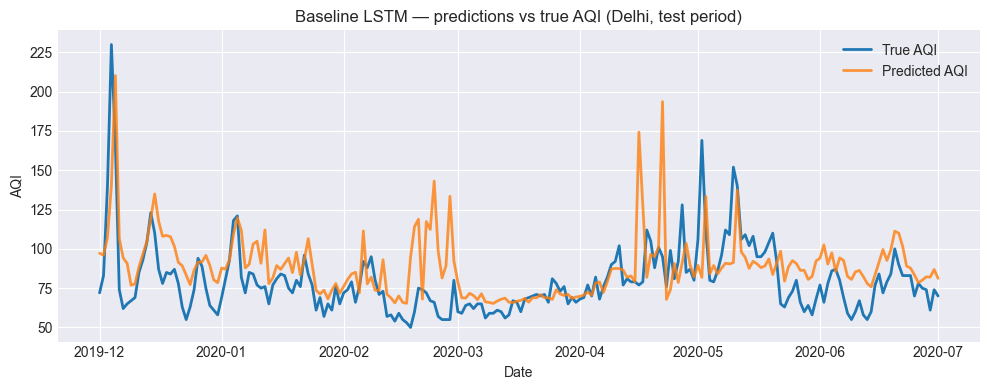

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Build a small DataFrame for plotting
df_test_plot = test_df.copy().reset_index(drop=True)
df_test_plot = df_test_plot.iloc[len(df_test_plot) - len(test_raw_aqi_alt):].copy()
df_test_plot["AQI_true"] = test_raw_aqi_alt
df_test_plot["AQI_pred"] = test_preds_alt

city_to_plot = "Delhi"  # choose any city in the dataset
mask = df_test_plot["city"] == city_to_plot

plt.figure(figsize=(10, 4))
plt.plot(df_test_plot.loc[mask, "date"], df_test_plot.loc[mask, "AQI_true"],
         label="True AQI", linewidth=2)
plt.plot(df_test_plot.loc[mask, "date"], df_test_plot.loc[mask, "AQI_pred"],
         label="Predicted AQI", linewidth=2, alpha=0.8)

plt.title(f"Baseline LSTM — predictions vs true AQI ({city_to_plot}, test period)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Training loop

Standard PyTorch training with:
- **MSE loss** on `log1p(AQI)` (matches other models)
- **Adam** optimiser with weight decay (1e-5) and `ReduceLROnPlateau` scheduling
- **Gradient clipping** at norm 1.0 to stabilise LSTM training
- **Early stopping** on validation RMSE (original AQI scale)

In [6]:
def train_model(model, train_loader, val_loader, val_raw_aqi,
                epochs=80, lr=1e-3, weight_decay=1e-5, patience=10, device=DEVICE,
                verbose=True):
    """Train *model*, returning the best checkpoint and history.

    Returns
    -------
    model : nn.Module
        Model loaded with the best validation checkpoint.
    train_losses : list[float]
        Per-epoch training loss (MSE on log1p(AQI)).
    val_rmses : list[float]
        Per-epoch validation RMSE (on original AQI scale).
    best_rmse : float
        Best validation RMSE.
    best_mae : float
        Validation MAE at the epoch where RMSE was best.
    best_r2 : float
        Validation R² at the epoch where RMSE was best.
    """
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5,
    )
    criterion = nn.MSELoss()

    best_rmse = float('inf')
    best_mae = None
    best_r2 = None
    best_state = None
    wait = 0
    train_losses, val_rmses = [], []

    for epoch in range(epochs):
        # --- train ---
        model.train()
        running = 0.0
        n = 0
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            optimizer.zero_grad()
            loss = criterion(model(X_b), y_b)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            running += loss.item()
            n += 1
        avg_loss = running / max(n, 1)
        train_losses.append(avg_loss)

        # --- validate ---
        model.eval()
        preds = []
        with torch.no_grad():
            for X_b, _ in val_loader:
                preds.append(model(X_b.to(device)).cpu().numpy())
        preds = np.clip(np.expm1(np.concatenate(preds)), 0, None)
        rmse = float(np.sqrt(mean_squared_error(val_raw_aqi, preds)))
        mae = float(mean_absolute_error(val_raw_aqi, preds))
        r2 = float(r2_score(val_raw_aqi, preds))
        val_rmses.append(rmse)

        scheduler.step(rmse)

        if rmse < best_rmse:
            best_rmse = rmse
            best_mae = mae
            best_r2 = r2
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1

        if verbose and ((epoch + 1) % 10 == 0 or epoch == 0):
            print(f'  epoch {epoch+1:3d} | loss {avg_loss:.4f} '
                  f'| val RMSE {rmse:.2f}')

        if wait >= patience:
            if verbose:
                print(f'  early stop @ epoch {epoch+1}')
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, train_losses, val_rmses, best_rmse, best_mae, best_r2


## 5. Hyperparameter search

We search over **window size**, **hidden size**, **number of LSTM layers**,
and **learning rate** using the Oct–Nov 2019 validation window.
The combination with the lowest validation RMSE is used for the final model.

In [7]:
VAL_CUTOFF = pd.Timestamp('2019-10-01')

full_train_df = df[df['date'] < CUTOFF_DATE].copy().reset_index(drop=True)
test_df       = df[df['date'] >= CUTOFF_DATE].copy().reset_index(drop=True)

train_sub_df = full_train_df[full_train_df['date'] < VAL_CUTOFF].reset_index(drop=True)
val_sub_df   = full_train_df[full_train_df['date'] >= VAL_CUTOFF].reset_index(drop=True)

print(f'train subset : {len(train_sub_df):,}')
print(f'val subset   : {len(val_sub_df):,}')
print(f'test         : {len(test_df):,}')

train subset : 18,431
val subset   : 1,319
test         : 5,100


In [8]:
window_sizes       = [7, 14, 30]
hidden_sizes       = [64, 128]
num_layers_options = [1, 2]
learning_rates     = [1e-3, 5e-4]

grid_results = []

for w in window_sizes:
    train_ds = AQISequenceDataset(
        train_sub_df, seq_feature_cols, w, fit_scaler=True)
    val_ds = AQISequenceDataset(
        val_sub_df, seq_feature_cols, w, scaler=train_ds.scaler)

    if len(train_ds) == 0 or len(val_ds) == 0:
        print(f'window={w}: skipping (empty dataset)')
        continue

    val_raw_aqi = np.array(val_ds.raw_targets)
    train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)

    for h in hidden_sizes:
        for nl in num_layers_options:
            for lr in learning_rates:
                tag = f'w={w} h={h} L={nl} lr={lr}'
                print(f'\n>>> {tag}')

                model = AQIForecaster(
                    input_size=len(seq_feature_cols),
                    hidden_size=h,
                    num_layers=nl,
                    dropout=0.2,
                )
                _, _, _, best_rmse, best_mae, best_r2 = train_model(
                    model, train_loader, val_loader, val_raw_aqi,
                    epochs=80, lr=lr, weight_decay=1e-5, patience=10,
                    device=DEVICE, verbose=False,
                )
                grid_results.append(dict(
                    window=w, hidden=h, layers=nl,
                    lr=lr, val_rmse=best_rmse
                ))
                print(f'    val RMSE = {best_rmse:.2f} | MAE = {best_mae:.2f} | R² = {best_r2:.4f}')

grid_df = pd.DataFrame(grid_results).sort_values('val_rmse')
print('\n=== search results (top 10) ===')
print(grid_df.head(10).to_string(index=False))


>>> w=7 h=64 L=1 lr=0.001
    val RMSE = 57.76 | MAE = 30.82 | R² = 0.8260

>>> w=7 h=64 L=1 lr=0.0005
    val RMSE = 64.94 | MAE = 36.14 | R² = 0.7801

>>> w=7 h=64 L=2 lr=0.001
    val RMSE = 58.95 | MAE = 32.41 | R² = 0.8187

>>> w=7 h=64 L=2 lr=0.0005
    val RMSE = 58.72 | MAE = 33.24 | R² = 0.8202

>>> w=7 h=128 L=1 lr=0.001
    val RMSE = 54.91 | MAE = 31.43 | R² = 0.8428

>>> w=7 h=128 L=1 lr=0.0005
    val RMSE = 60.09 | MAE = 34.39 | R² = 0.8117

>>> w=7 h=128 L=2 lr=0.001
    val RMSE = 59.88 | MAE = 35.29 | R² = 0.8130

>>> w=7 h=128 L=2 lr=0.0005
    val RMSE = 58.39 | MAE = 33.37 | R² = 0.8222

>>> w=14 h=64 L=1 lr=0.001
    val RMSE = 66.64 | MAE = 39.44 | R² = 0.7113

>>> w=14 h=64 L=1 lr=0.0005
    val RMSE = 72.41 | MAE = 44.21 | R² = 0.6592

>>> w=14 h=64 L=2 lr=0.001
    val RMSE = 65.43 | MAE = 38.30 | R² = 0.7217

>>> w=14 h=64 L=2 lr=0.0005
    val RMSE = 68.23 | MAE = 39.56 | R² = 0.6974

>>> w=14 h=128 L=1 lr=0.001
    val RMSE = 66.27 | MAE = 39.69 | R² = 0.7

best config:
window        7.000000
hidden      128.000000
layers        1.000000
lr            0.001000
val_rmse     54.906027


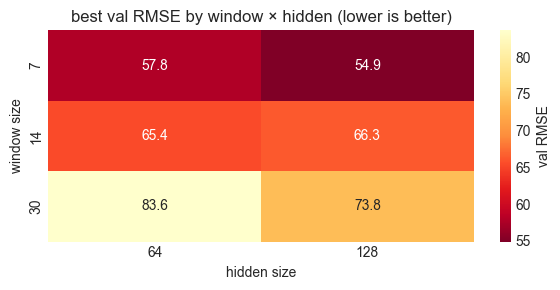

In [9]:
best_cfg = grid_df.iloc[0]
print('best config:')
print(best_cfg.to_string())

BEST_W  = int(best_cfg['window'])
BEST_H  = int(best_cfg['hidden'])
BEST_NL = int(best_cfg['layers'])
BEST_LR = float(best_cfg['lr'])

# heatmap of val RMSE vs window size and hidden size (avg over lr/layers)
pivot = grid_df.groupby(['window', 'hidden'])['val_rmse'].min().unstack()
fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd_r', ax=ax,
            cbar_kws={'label': 'val RMSE'})
ax.set(xlabel='hidden size', ylabel='window size',
       title='best val RMSE by window × hidden (lower is better)')
plt.tight_layout()
plt.show()

## 6. Train final model on full training data

Re-train the best configuration using **all** data before the test cutoff
(2019-12-01). A small portion (last 2 months) is still held out for early
stopping so we don't overfit.

In [12]:
# rebuild datasets with best window size
train_ds_final = AQISequenceDataset(
    train_sub_df, seq_feature_cols, BEST_W, fit_scaler=True)
val_ds_final = AQISequenceDataset(
    val_sub_df, seq_feature_cols, BEST_W, scaler=train_ds_final.scaler)

val_raw_aqi_final = np.array(val_ds_final.raw_targets)

train_loader_final = DataLoader(train_ds_final, batch_size=128, shuffle=True)
val_loader_final   = DataLoader(val_ds_final,   batch_size=256, shuffle=False)

final_model = AQIForecaster(
    input_size=len(seq_feature_cols),
    hidden_size=BEST_H,
    num_layers=BEST_NL,
    dropout=0.2,
)

print(f'training final model  w={BEST_W} h={BEST_H} '
      f'L={BEST_NL} lr={BEST_LR}')
print(f'  train seqs: {len(train_ds_final):,}  |  val seqs: {len(val_ds_final):,}')

final_model, train_losses, val_rmses, best_val,_,_ = train_model(
    final_model, train_loader_final, val_loader_final,
    val_raw_aqi_final,
    epochs=150, lr=BEST_LR, weight_decay=1e-5, patience=15,
    device=DEVICE, verbose=True,
)
print(f'\nbest validation RMSE: {best_val:.2f}')

training final model  w=7 h=128 L=1 lr=0.001
  train seqs: 16,122  |  val seqs: 1,050
  epoch   1 | loss 4.0986 | val RMSE 83.77
  epoch  10 | loss 0.0985 | val RMSE 58.69
  epoch  20 | loss 0.0881 | val RMSE 60.19
  epoch  30 | loss 0.0826 | val RMSE 58.06
  epoch  40 | loss 0.0763 | val RMSE 66.89
  early stop @ epoch 40

best validation RMSE: 56.19


## 7. Test-set evaluation

Evaluate on the held-out test period (≥ 2019-12-01) using the same
`evaluate()` and `save_results()` helpers as every other model.

In [ ]:
test_ds = AQISequenceDataset(
    test_df, seq_feature_cols, BEST_W, scaler=train_ds_final.scaler)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False)
test_raw_aqi = np.array(test_ds.raw_targets)

print(f'test sequences: {len(test_ds):,}')

final_model.eval()
test_preds = []
with torch.no_grad():
    for X_b, _ in test_loader:
        test_preds.append(final_model(X_b.to(DEVICE)).cpu().numpy())
test_preds = np.clip(np.expm1(np.concatenate(test_preds)), 0, None)

model_label = (f'LSTM (w={BEST_W}, h={BEST_H}, '
               f'L={BEST_NL}, lr={BEST_LR})')

result = evaluate(test_raw_aqi, test_preds, label=model_label)
save_results(result, 'lstm')

test sequences: 4,552

──────────────────────────────────────────────────────
  LSTM (w=7, h=128, L=1, lr=0.001)
──────────────────────────────────────────────────────
  RMSE :    37.23
  MAE  :    21.06
  R²   :   0.8306
  MAE by AQI category:
              Good:   13.94  (n=476)
      Satisfactory:   11.43  (n=1,929)
          Moderate:   23.00  (n=1,540)
              Poor:   44.70  (n=349)
         Very Poor:   40.68  (n=203)
            Severe:  143.44  (n=55)
Saved → results\lstm_metrics.json


## 8. Visualisations

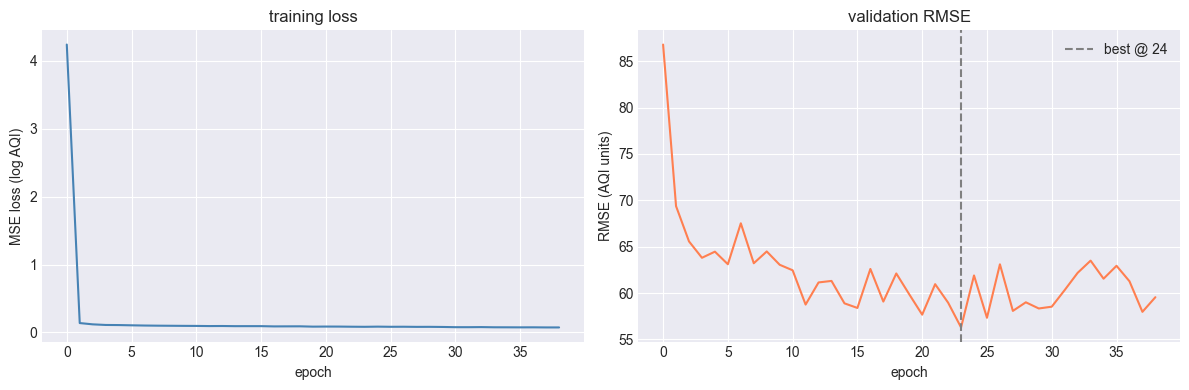

In [ ]:
# --- training curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_losses, color='steelblue', linewidth=1.5)
ax1.set(xlabel='epoch', ylabel='MSE loss (log AQI)',
        title='training loss')

ax2.plot(val_rmses, color='coral', linewidth=1.5)
best_epoch = int(np.argmin(val_rmses))
ax2.axvline(best_epoch, ls='--', color='grey', label=f'best @ {best_epoch+1}')
ax2.set(xlabel='epoch', ylabel='RMSE (AQI units)',
        title='validation RMSE')
ax2.legend()

plt.tight_layout()
plt.show()

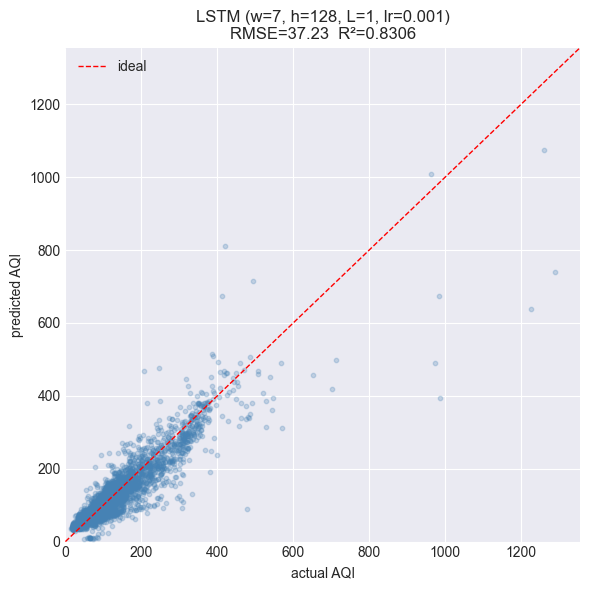

In [ ]:
# --- predicted vs actual scatter ---
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(test_raw_aqi, test_preds, alpha=0.25, s=10, color='steelblue')
lims = [0, max(test_raw_aqi.max(), test_preds.max()) * 1.05]
ax.plot(lims, lims, '--', color='red', linewidth=1, label='ideal')
ax.set(xlabel='actual AQI', ylabel='predicted AQI',
       title=f'{model_label}\nRMSE={result["RMSE"]:.2f}  '
             f'R²={result["R2"]:.4f}',
       xlim=lims, ylim=lims)
ax.legend()
plt.tight_layout()
plt.show()

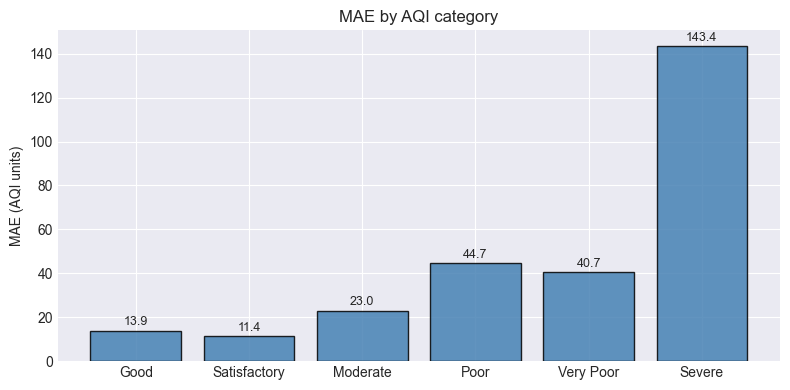

In [ ]:
# --- per-category MAE ---
cat_keys = [f'MAE_{c}' for c in AQI_LABELS if f'MAE_{c}' in result]
cat_vals = [result[k] for k in cat_keys]
cat_names = [k.replace('MAE_', '') for k in cat_keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cat_names, cat_vals, color='steelblue', edgecolor='black',
              alpha=0.85)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
            f'{b.get_height():.1f}', ha='center', va='bottom', fontsize=9)
ax.set(ylabel='MAE (AQI units)', title='MAE by AQI category')
plt.tight_layout()
plt.show()

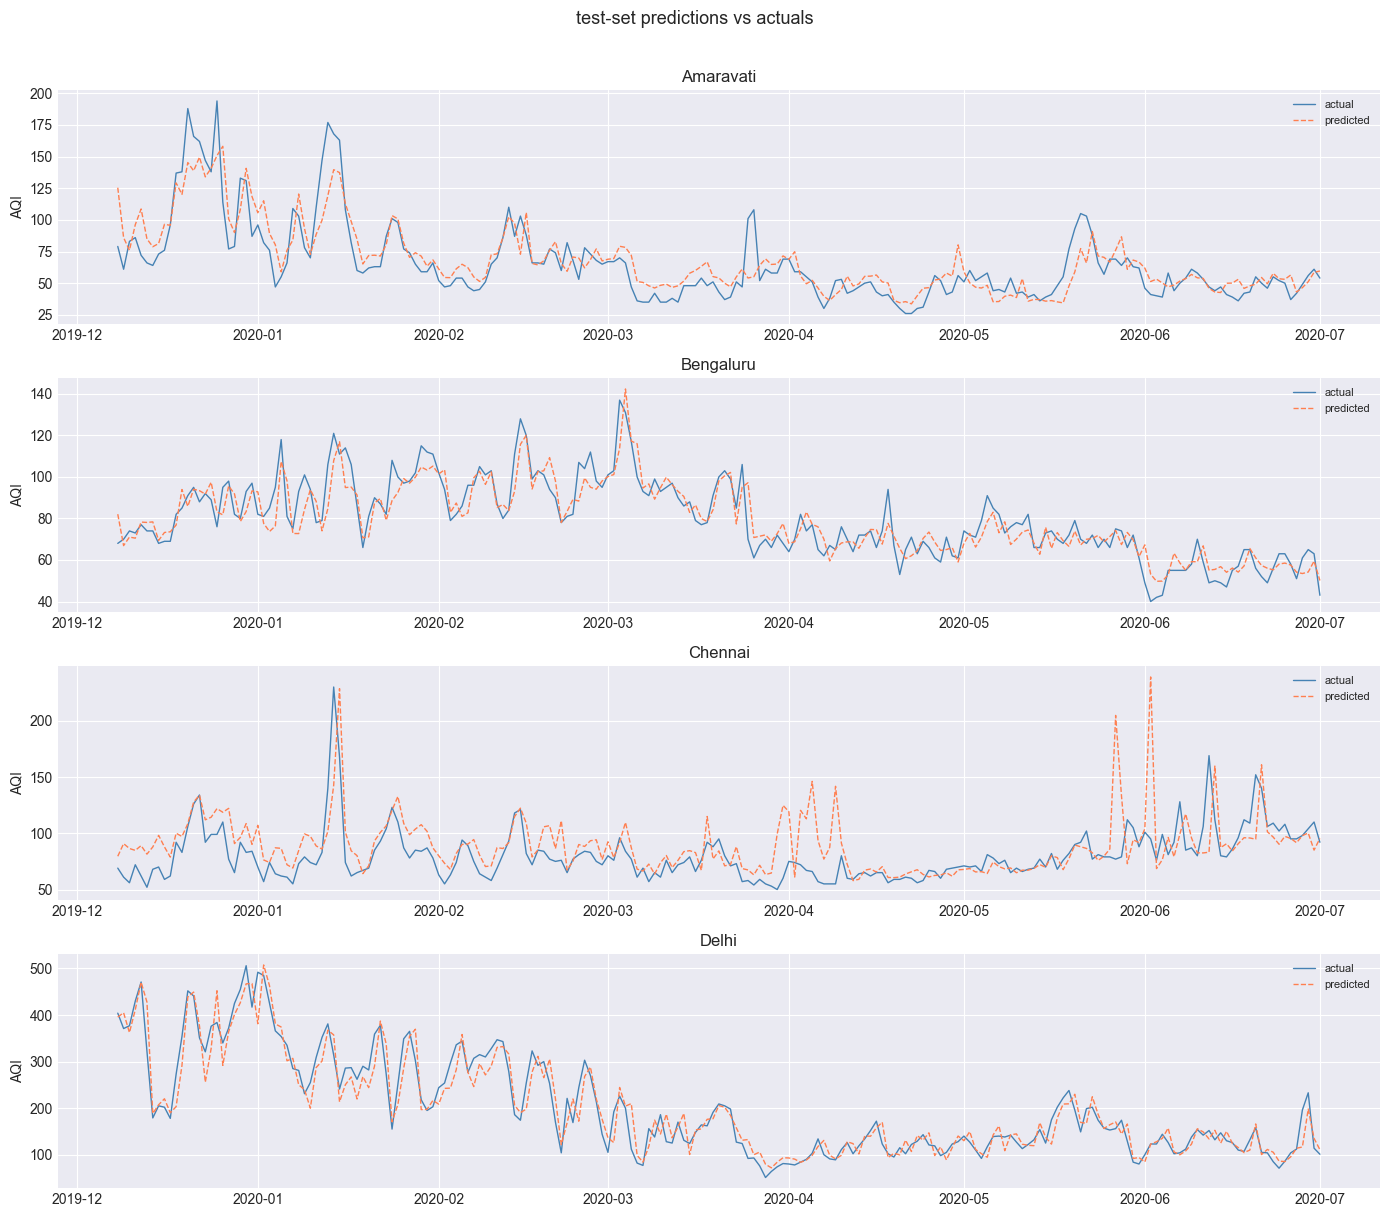

In [ ]:
# --- time-series overlay for a few cities ---
test_dates = np.array(test_ds.target_dates)
test_cities = np.array(test_ds.target_cities)

sample_cities = pd.Series(test_cities).value_counts().head(4).index.tolist()

fig, axes = plt.subplots(len(sample_cities), 1,
                         figsize=(14, 3 * len(sample_cities)),
                         sharex=False)
if len(sample_cities) == 1:
    axes = [axes]

for ax, city in zip(axes, sample_cities):
    mask = test_cities == city
    d = pd.to_datetime(test_dates[mask])
    order = np.argsort(d)
    d = d[order]
    actual = test_raw_aqi[mask][order]
    pred   = test_preds[mask][order]

    ax.plot(d, actual, label='actual', color='steelblue', linewidth=1)
    ax.plot(d, pred,   label='predicted', color='coral', linewidth=1,
            linestyle='--')
    ax.set(ylabel='AQI', title=city)
    ax.legend(loc='upper right', fontsize=8)

plt.suptitle('test-set predictions vs actuals', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Comparison of baseline vs tuned vs ridge

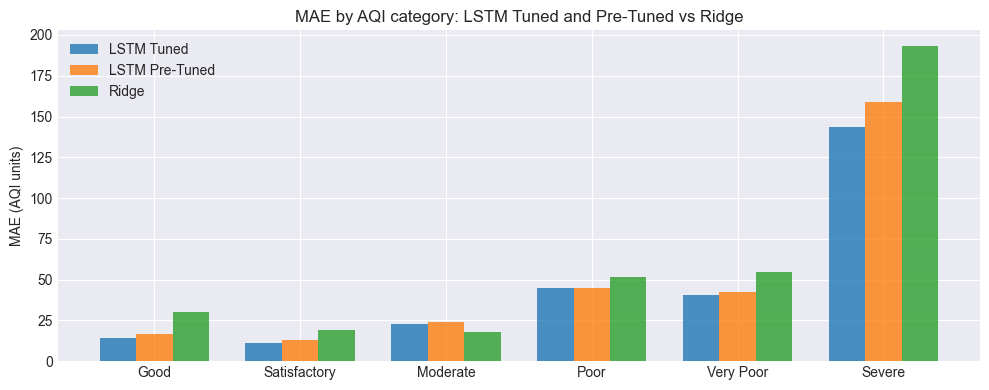

In [21]:
import numpy as np
import matplotlib.pyplot as plt

categories = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]


mae_lstm_best = [13.9, 11.4, 23.0, 44.7, 40.7, 143.4]  

mae_ridge     = [30.14,
                 19.40,
                 17.62,
                 51.63,
                 54.75,
                 193.14]

mae_lstm_alt = [
    16.48,
    13.11,
    24.02,
    44.64,
    42.10,
    158.77,
]

x = np.arange(len(categories))
width = 0.25

plt.figure(figsize=(10, 4))
plt.bar(x - width,        mae_lstm_best, width, label="LSTM Tuned", alpha=0.8)
plt.bar(x,        mae_lstm_alt,  width, label="LSTM Pre-Tuned",alpha=0.8)
plt.bar(x + width,                mae_ridge,     width, label="Ridge",               alpha=0.8)

plt.xticks(x, categories)
plt.ylabel("MAE (AQI units)")
plt.title("MAE by AQI category: LSTM Tuned and Pre-Tuned vs Ridge")
plt.legend()
plt.tight_layout()
plt.show()